In [ ]:
#supply chain bottleneck analysis

In [ ]:
# clean the data using python

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('/Users/ritikchaudhary/Downloads/DataCoSupplyChainDataset.csv', encoding='latin1')

# Check shape & nulls
print(df.shape)
print(df.isnull().sum())

# Drop irrelevant columns
df.drop(columns=['Customer Zipcode', 'Product Description'], inplace=True)

# Fix date columns
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

# Create delivery delay column (key metric)
df['Delivery_Delay_Days'] = (
    df['Days for shipment (scheduled)'] - df['Days for shipping (real)']
)
df['Is_Late'] = df['Delivery_Delay_Days'] > 0

# Flag late deliveries
df['Is_Late'] = df['Delivery_Delay_Days'] > 0

print("Late deliveries %:", df['Is_Late'].mean() * 100)

(180519, 53)
Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                     

In [ ]:
# Analyze bottlenecks with pandas

In [4]:
# Which shipping mode has most delays?
shipping_delay = df.groupby('Shipping Mode')['Is_Late'].mean().sort_values(ascending=False)
print(shipping_delay)

# Which product category has highest delay?
category_delay = df.groupby('Category Name')['Delivery_Delay_Days'].mean().sort_values(ascending=False).head(10)

# Which region is worst performing?
region_delay = df.groupby('Order Region')['Is_Late'].mean().sort_values(ascending=False)

# Late delivery vs profit loss
profit_loss = df[df['Is_Late'] == True]['Order Profit Per Order'].mean()
profit_ok = df[df['Is_Late'] == False]['Order Profit Per Order'].mean()
print("Late profit:", profit_loss)
print("OnTime profit:", profit_ok)
print(f"Avg profit (late): {profit_loss:.2f} | Avg profit (on-time): {profit_ok:.2f}")

Shipping Mode
First Class       0.0
Same Day          0.0
Second Class      0.0
Standard Class    0.0
Name: Is_Late, dtype: float64
Avg profit (late): nan | Avg profit (on-time): 21.97


In [ ]:
#visualize insights

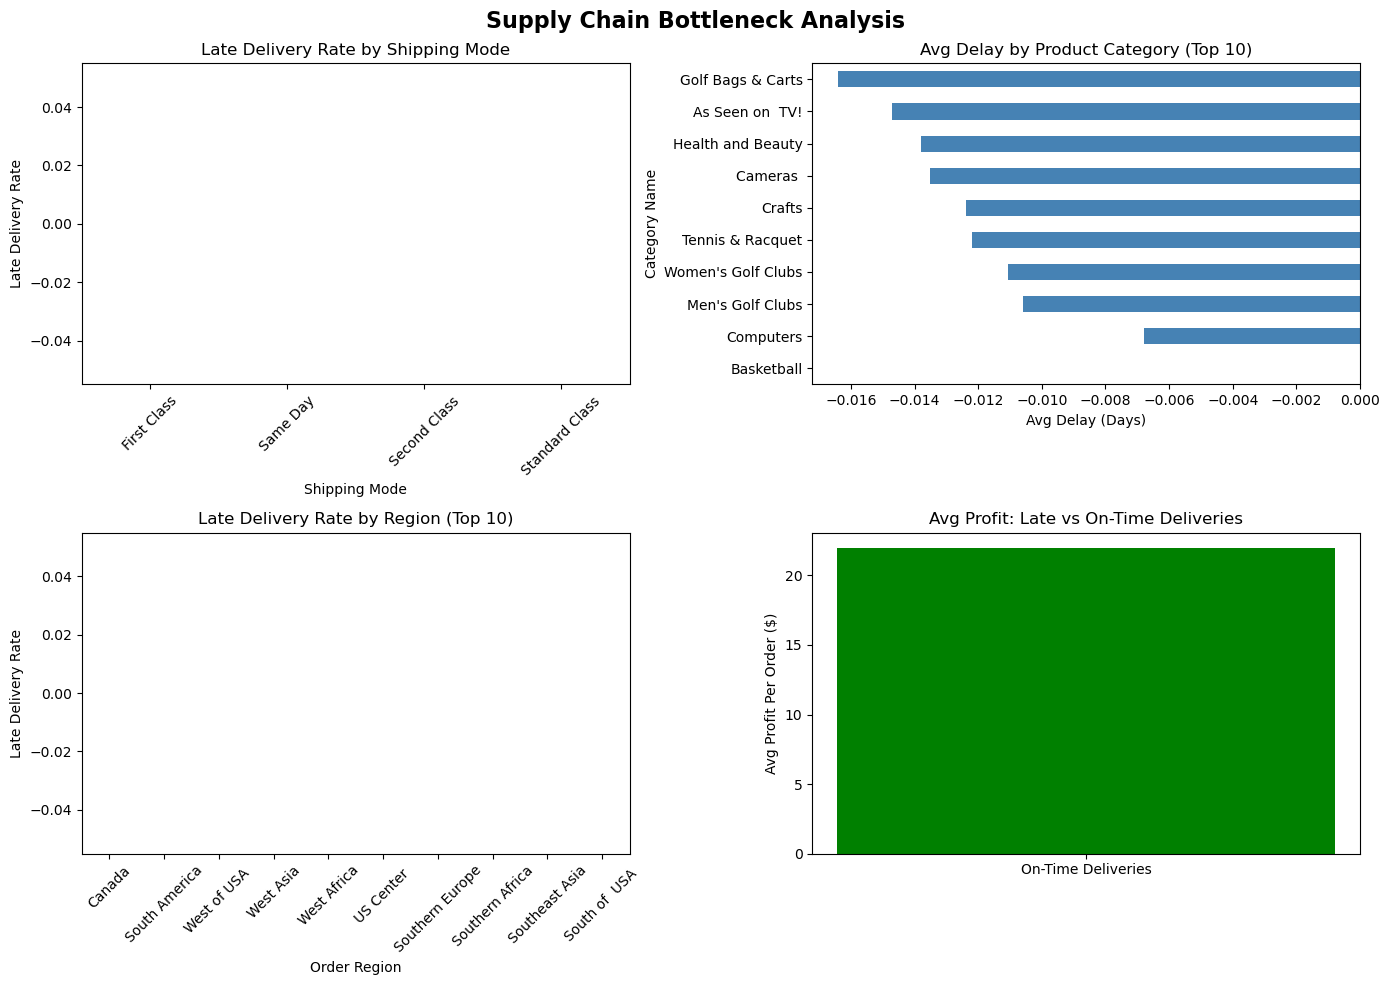

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Supply Chain Bottleneck Analysis', fontsize=16, fontweight='bold')

# 1. Late delivery by shipping mode
shipping_delay.plot(kind='bar', ax=axes[0,0], color='tomato')
axes[0,0].set_title('Late Delivery Rate by Shipping Mode')
axes[0,0].set_ylabel('Late Delivery Rate')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Top delayed categories
category_delay.plot(kind='barh', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Avg Delay by Product Category (Top 10)')
axes[0,1].set_xlabel('Avg Delay (Days)')

# 3. Region-wise late delivery
region_delay.head(10).plot(kind='bar', ax=axes[1,0], color='orange')
axes[1,0].set_title('Late Delivery Rate by Region (Top 10)')
axes[1,0].set_ylabel('Late Delivery Rate')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Profit comparison
axes[1,1].bar(['Late Deliveries', 'On-Time Deliveries'], [profit_loss, profit_ok], color=['red', 'green'])
axes[1,1].set_title('Avg Profit: Late vs On-Time Deliveries')
axes[1,1].set_ylabel('Avg Profit Per Order ($)')

plt.tight_layout()
import os
os.makedirs('dashboard', exist_ok=True)  # creates folder if not exists


plt.savefig('dashboard/bottleneck_visuals.png', dpi=150)  # removed ../
plt.show()
